In [2]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 13,
    'font.family': 'serif',
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'axes.labelsize': 13,
    'legend.fontsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'lines.linewidth': 2,
    'lines.markersize': 6,
})

## Noise Analysis — Corrected Methodology

This notebook studies how gate-level and readout noise distort the oscillation
probability, using the corrected atmospheric-channel parameters (θ₂₃=43.3°,
Δm²=2.5×10⁻³ eV²) and comparing against the exact statevector baseline
established in Notebook 02.

In [3]:
!pip install qiskit qiskit-aer qiskit-ibm-runtime -q

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, amplitude_damping_error, phase_damping_error, ReadoutError
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
theta_23_deg = 43.3
theta = np.deg2rad(theta_23_deg)
delta_m2 = 2.5e-3
L_over_E_vals = np.linspace(0.1, 2000, 120)

def exact_transition_probability(L_over_E, theta, delta_m2):
    phi = 2 * 1.27 * delta_m2 * L_over_E
    qc = QuantumCircuit(1)
    qc.ry(2*theta, 0)
    qc.rz(phi, 0)
    qc.ry(-2*theta, 0)
    return Statevector.from_instruction(qc).probabilities()[1]

P_exact = np.array([exact_transition_probability(L, theta, delta_m2) for L in L_over_E_vals])

def run_noisy_circuit(L_over_E, theta, delta_m2, noise_model, shots=4000, seed=SEED):
    phi = 2 * 1.27 * delta_m2 * L_over_E
    qc = QuantumCircuit(1, 1)
    qc.ry(2*theta, 0)
    qc.rz(phi, 0)
    qc.ry(-2*theta, 0)
    qc.measure(0, 0)
    sim = AerSimulator(noise_model=noise_model, seed_simulator=seed)
    result = sim.run(qc, shots=shots).result()
    counts = result.get_counts()
    return counts.get('1', 0) / shots

def build_noise_model(kind, strength, readout_error=0.0):
    nm = NoiseModel()
    if kind == "depolarizing":
        err = depolarizing_error(strength, 1)
    elif kind == "amplitude_damping":
        err = amplitude_damping_error(strength)
    elif kind == "phase_damping":
        err = phase_damping_error(strength)
    nm.add_all_qubit_quantum_error(err, ['ry', 'rz'])
    if readout_error > 0:
        ro_error = ReadoutError([[1-readout_error, readout_error], [readout_error, 1-readout_error]])
        nm.add_all_qubit_readout_error(ro_error)
    return nm

print("Setup complete. P_exact range:", P_exact.min(), P_exact.max())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.7/120.7 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.7/94.7 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.2/224.2 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/541.5 kB 35.5 MB/s eta 0:00:00
Setup complete. P_exact range: 1.0045168625039631e-0

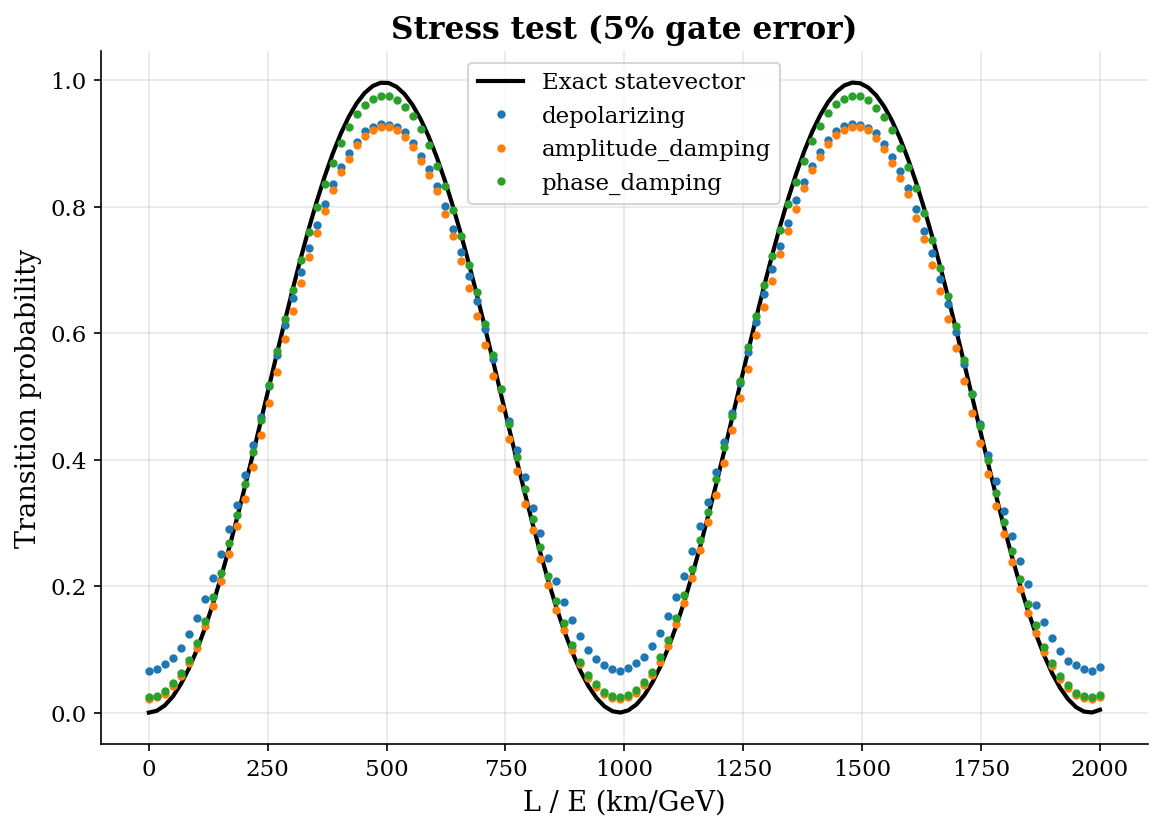

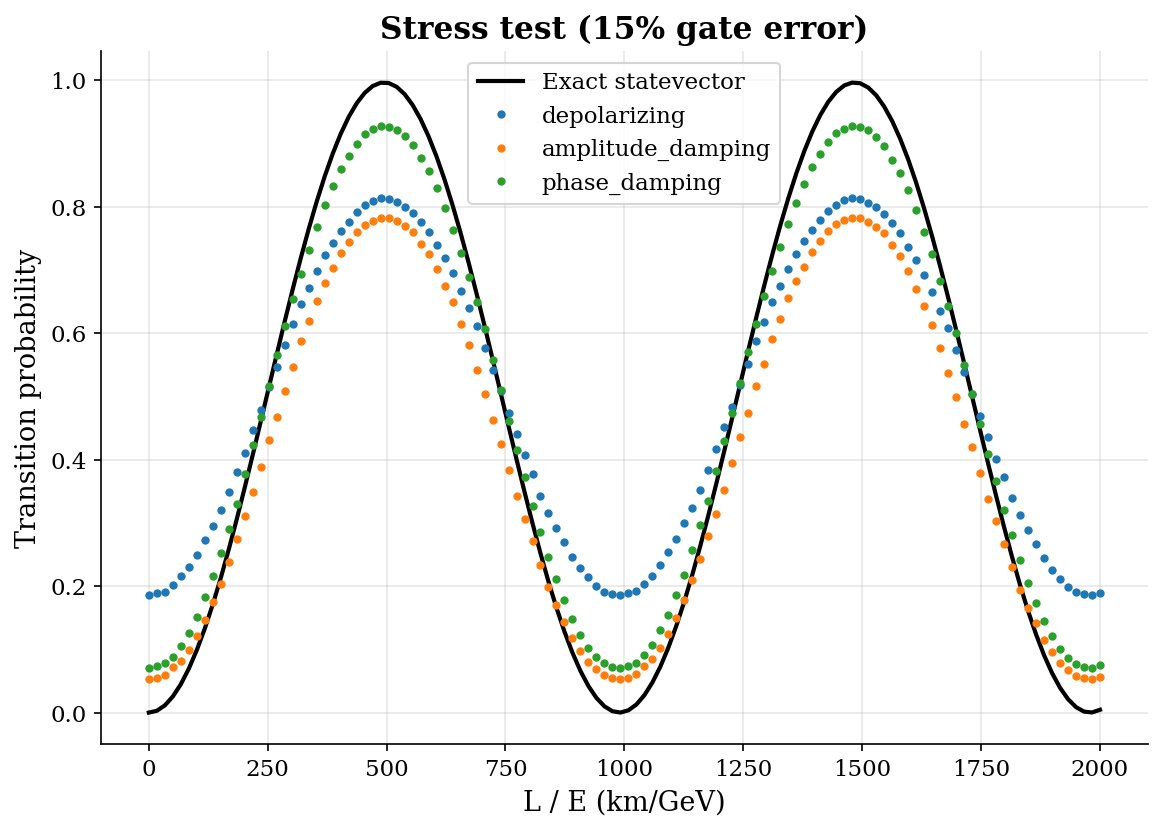

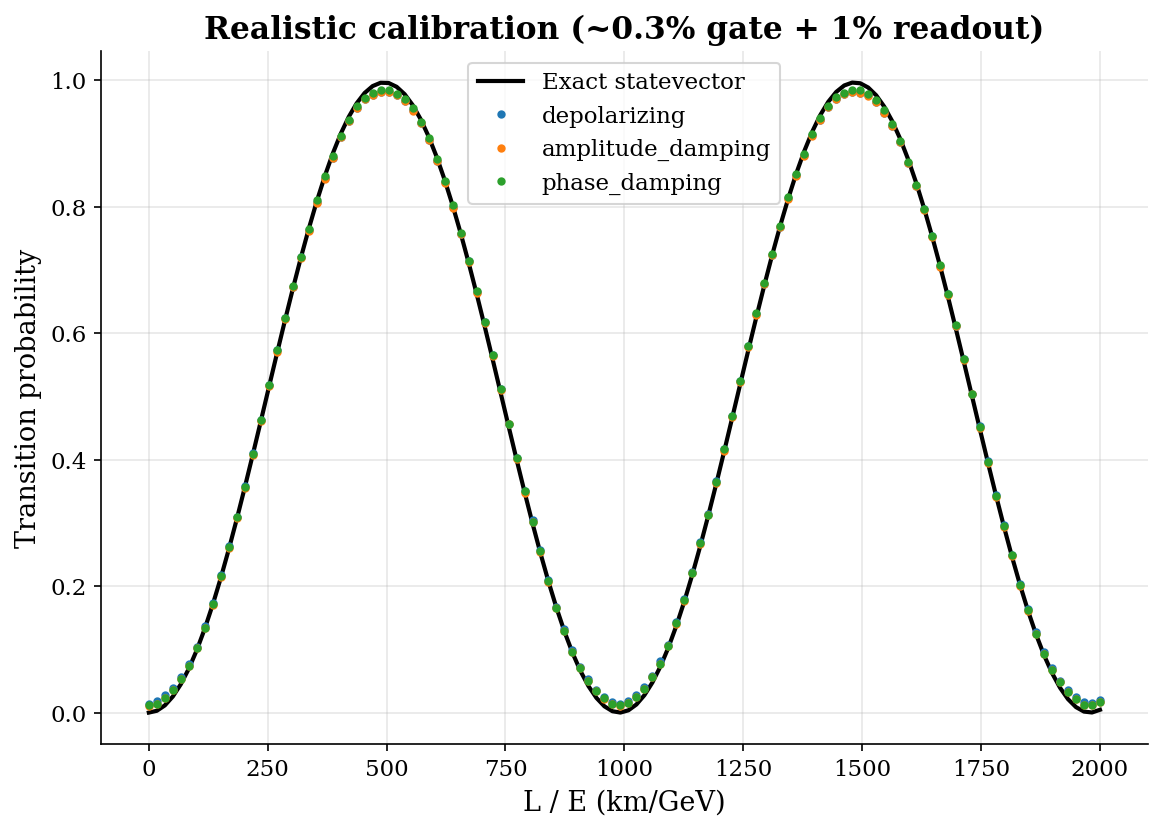


=== Stress test (5% gate error) ===
Noise type                  MAE   Peak suppression   Trough elevation
depolarizing             0.0403             0.0660             0.0662
amplitude_damping        0.0318             0.0702             0.0222
phase_damping            0.0122             0.0210             0.0250

=== Stress test (15% gate error) ===
Noise type                  MAE   Peak suppression   Trough elevation
depolarizing             0.1182             0.1830             0.1865
amplitude_damping        0.0984             0.2137             0.0532
phase_damping            0.0426             0.0690             0.0702

=== Realistic calibration (~0.3% gate + 1% readout) ===
Noise type                  MAE   Peak suppression   Trough elevation
depolarizing             0.0067             0.0145             0.0142
amplitude_damping        0.0054             0.0147             0.0110
phase_damping            0.0051             0.0110             0.0112


In [4]:
noise_types = ["depolarizing", "amplitude_damping", "phase_damping"]
configs = {
    "stress_5pct":  {"strength": 0.05, "readout": 0.0,  "label": "Stress test (5% gate error)"},
    "stress_15pct": {"strength": 0.15, "readout": 0.0,  "label": "Stress test (15% gate error)"},
    "realistic":    {"strength": 0.003, "readout": 0.01, "label": "Realistic calibration (~0.3% gate + 1% readout)"},
}

results = {}
for config_name, cfg in configs.items():
    results[config_name] = {}
    for kind in noise_types:
        nm = build_noise_model(kind, cfg["strength"], readout_error=cfg["readout"])
        P = np.array([run_noisy_circuit(L, theta, delta_m2, nm) for L in L_over_E_vals])
        results[config_name][kind] = P

for config_name, cfg in configs.items():
    plt.figure(figsize=(9,6))
    plt.plot(L_over_E_vals, P_exact, 'k-', linewidth=2, label="Exact statevector")
    for kind in noise_types:
        plt.plot(L_over_E_vals, results[config_name][kind], 'o', markersize=3, label=kind)
    plt.xlabel("L / E (km/GeV)")
    plt.ylabel("Transition probability")
    plt.title(cfg["label"])
    plt.legend()
    plt.grid(True)
    plt.savefig(f"fig_noise_{config_name}.png", dpi=200, bbox_inches='tight')
    plt.show()

peak_idx = np.argmax(P_exact)
trough_idx = np.argmin(P_exact[10:]) + 10
for config_name, cfg in configs.items():
    print(f"\n=== {cfg['label']} ===")
    print(f"{'Noise type':<20} {'MAE':>10} {'Peak suppression':>18} {'Trough elevation':>18}")
    for kind in noise_types:
        P = results[config_name][kind]
        mae = np.mean(np.abs(P_exact - P))
        peak_suppression = P_exact[peak_idx] - P[peak_idx]
        trough_elevation = P[trough_idx] - P_exact[trough_idx]
        print(f"{kind:<20} {mae:>10.4f} {peak_suppression:>18.4f} {trough_elevation:>18.4f}")

## Why Use a Quantum Computer for This Problem?

It is fair to ask: the single-qubit circuit used here (three gates: RY, RZ, RY)
is trivially solvable on a classical computer in microseconds using basic
trigonometry. So why frame this as a "quantum simulation" at all?

**Honest answer for the two-flavor case:** it isn't strictly necessary. A
classical computer calculates the exact two-flavor oscillation formula
instantly, with no advantage from quantum hardware. This project's two-flavor
circuit is best understood as a **minimal, verifiable proof-of-concept** — a
controlled testbed for validating that a quantum circuit can correctly encode
oscillation physics, before addressing where quantum simulation becomes
genuinely necessary.

**Where quantum simulation stops being optional:**

1. **Three-flavor and beyond**: requires at least 2 qubits and entangling
   gates to represent the full PMNS matrix (3 mixing angles, a CP-violating
   phase, 2 independent mass splittings).

2. **Many-body neutrino systems**: dense neutrino environments (e.g.
   supernovae) require simulating entangled many-body states, where classical
   cost grows exponentially (2^N for N neutrinos) — the regime where quantum
   computers offer genuine, necessary advantage.

**Positioning of this project:** deliberately in the tractable, verifiable
regime — validating methodology (circuit design, noise behavior, hardware
reliability) on a system small enough to check against exact theory, as a
necessary first step before the many-body regime where quantum advantage
becomes real.

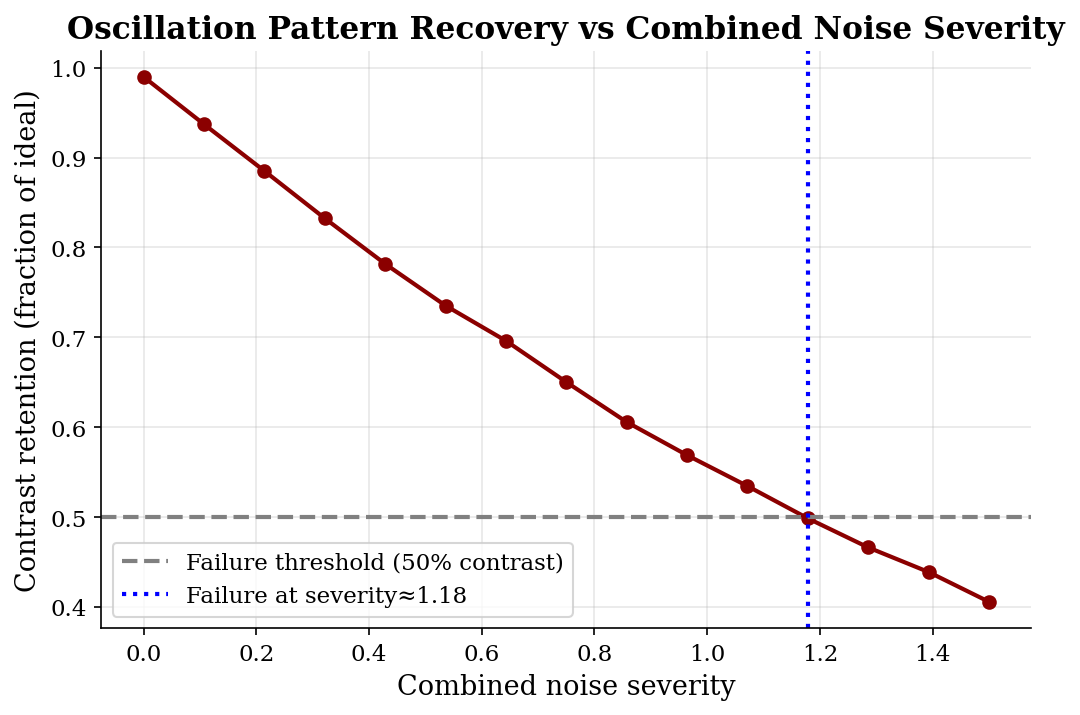

Threshold crossed at severity ≈ 1.179


In [5]:
def build_combined_noise_model(severity, readout_error_base=0.01):
    nm = NoiseModel()
    dep_err = depolarizing_error(0.10 * severity, 1)
    amp_err = amplitude_damping_error(0.10 * severity)
    phase_err = phase_damping_error(0.05 * severity)
    combined = dep_err.compose(amp_err).compose(phase_err)
    nm.add_all_qubit_quantum_error(combined, ['ry', 'rz'])
    ro_err = readout_error_base * (0.5 + severity)
    ro_error = ReadoutError([[1-ro_err, ro_err], [ro_err, 1-ro_err]])
    nm.add_all_qubit_readout_error(ro_error)
    return nm

def contrast_retention(P_curve, P_exact_curve):
    ideal_contrast = P_exact_curve.max() - P_exact_curve.min()
    measured_contrast = P_curve.max() - P_curve.min()
    return measured_contrast / ideal_contrast

severities_extended = np.linspace(0, 1.5, 15)
contrast_results_extended = []
for severity in severities_extended:
    nm = build_combined_noise_model(severity)
    P = np.array([run_noisy_circuit(L, theta, delta_m2, nm) for L in L_over_E_vals])
    contrast_results_extended.append(contrast_retention(P, P_exact))
contrast_results_extended = np.array(contrast_results_extended)

below_threshold = np.where(contrast_results_extended < 0.5)[0]
threshold_severity = severities_extended[below_threshold[0]] if len(below_threshold) > 0 else None

plt.figure(figsize=(8,5))
plt.plot(severities_extended, contrast_results_extended, 'o-', color='darkred')
plt.axhline(0.5, color='gray', linestyle='--', label='Failure threshold (50% contrast)')
if threshold_severity is not None:
    plt.axvline(threshold_severity, color='blue', linestyle=':', label=f'Failure at severity≈{threshold_severity:.2f}')
plt.xlabel("Combined noise severity")
plt.ylabel("Contrast retention (fraction of ideal)")
plt.title("Oscillation Pattern Recovery vs Combined Noise Severity")
plt.legend()
plt.grid(True)
plt.savefig("fig_contrast_threshold.png", dpi=200, bbox_inches='tight')
plt.show()

print(f"Threshold crossed at severity ≈ {threshold_severity:.3f}" if threshold_severity else "Not crossed")

## Extension to Three-Flavor Oscillation

Real neutrino oscillation involves three flavors (electron, muon, tau) mixing
via the full PMNS matrix, not the simplified two-flavor approximation used
in this project. This section outlines what a three-flavor quantum
simulation would require.

### The physics: PMNS matrix

The three-flavor mixing is described by the PMNS matrix, parameterized by
three mixing angles (θ₁₂, θ₂₃, θ₁₃), a CP-violating phase (δ_CP), and two
independent mass-squared differences (Δm²₂₁, Δm²₃₁). The oscillation
probability between any two flavors becomes a sum of interference terms
between all three mass eigenstates, rather than the single sin² term used
in the two-flavor case.

### Qubit requirements

A three-level quantum system (one for each flavor/mass state) cannot be
represented by a single qubit, which only has 2 basis states (|0⟩, |1⟩).
Two options exist:

1. **2 qubits (4-dimensional Hilbert space)** — the natural choice, since
   2 qubits give exactly 4 basis states, one more than needed (the unused
   4th state can be constrained to remain unpopulated via circuit design,
   or used as an ancilla for implementing the more complex rotations).
2. **A single qutrit** (3-level system) — more natural physically, but
   requires specialized hardware not generally available on standard
   IBM superconducting-qubit devices, which are built as 2-level systems.

Given standard hardware constraints, the 2-qubit approach is the practical
choice.

### Gate requirements

Instead of a single RY–RZ–RY sequence, the circuit would require:
- A sequence of rotation gates implementing the three mixing angles
  (generalizing RY(2θ) to a proper SU(3)-type rotation embedded in the
  2-qubit space)
- Entangling gates (e.g., CNOT) between the two qubits, since representing
  genuine three-state superposition and mixing requires the qubits to
  become correlated, not independently rotated
- A phase-evolution step generalizing RZ(φ) to encode two independent
  phase evolutions (corresponding to Δm²₂₁ and Δm²₃₁ simultaneously)
- An additional gate or phase term to encode δ_CP, the CP-violating phase
  — a feature with no analog in the two-flavor case at all

Overall circuit depth would grow from 3 gates to roughly 8-12 gates
(exact count depends on decomposition choices), and would require 2 qubits
instead of 1.

### Why this matters

The two-flavor case, tested in this project, is fully classically tractable
and serves as a validated foundation. The three-flavor case is still
classically tractable for a single neutrino, but is the natural next step
toward the genuinely classically-intractable regime discussed above
(many-body collective oscillations), since it introduces the core building
blocks — multi-qubit entanglement, multi-parameter phase encoding — that
scale directly into that harder regime. Implementing and validating the
three-flavor circuit against the known PMNS-based oscillation probabilities
would be a natural, well-scoped follow-up project building directly on
this one.

In [8]:
from google.colab import userdata
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit import transpile

QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token=userdata.get('IBM_TOKEN'), overwrite=True)
service = QiskitRuntimeService(channel="ibm_quantum_platform")

backend = service.backend("ibm_fez")

L_over_E_hardware = np.linspace(0.1, 2000, 20)
circuits = []
for L in L_over_E_hardware:
    phi = 2 * 1.27 * delta_m2 * L
    qc = QuantumCircuit(1, 1)
    qc.ry(2*theta, 0)
    qc.rz(phi, 0)
    qc.ry(-2*theta, 0)
    qc.measure(0, 0)
    circuits.append(transpile(qc, backend))

RAW_JOB_ID = "d9ptegh7s9kc73augqv0"
MITIGATED_JOB_ID = "d9ptegslp7es73b47h00"

job_raw = service.job(RAW_JOB_ID)
job_mitigated = service.job(MITIGATED_JOB_ID)
print("Raw status:", job_raw.status())
print("Mitigated status:", job_mitigated.status())

qiskit_runtime_service.__init__:WARNING:2026-08-17 10:39:23,428: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-08-17 10:39:23,429: Using instance: open-instance, plan: open


Raw status: DONE
Mitigated status: DONE


In [9]:
result_raw = job_raw.result()
result_mitigated = job_mitigated.result()

P_raw = np.array([result_raw[i].data.c.get_counts().get('1', 0) / 4000 for i in range(len(circuits))])
P_mitigated = np.array([result_mitigated[i].data.c.get_counts().get('1', 0) / 4000 for i in range(len(circuits))])
P_exact_hw = np.array([exact_transition_probability(L, theta, delta_m2) for L in L_over_E_hardware])

mae_raw = np.mean(np.abs(P_raw - P_exact_hw))
mae_mitigated = np.mean(np.abs(P_mitigated - P_exact_hw))

print(f"Backend: {backend.name}")
print(f"Raw MAE: {mae_raw:.4f}")
print(f"Mitigated MAE: {mae_mitigated:.4f}")
print(f"Change: {(1 - mae_mitigated/mae_raw)*100:+.1f}%")
print(f"\nSame array check — max diff between raw/mitigated: {np.max(np.abs(P_raw - P_mitigated)):.4f}")

Backend: ibm_fez
Raw MAE: 0.0099
Mitigated MAE: 0.0095
Change: +3.7%

Same array check — max diff between raw/mitigated: 0.0182


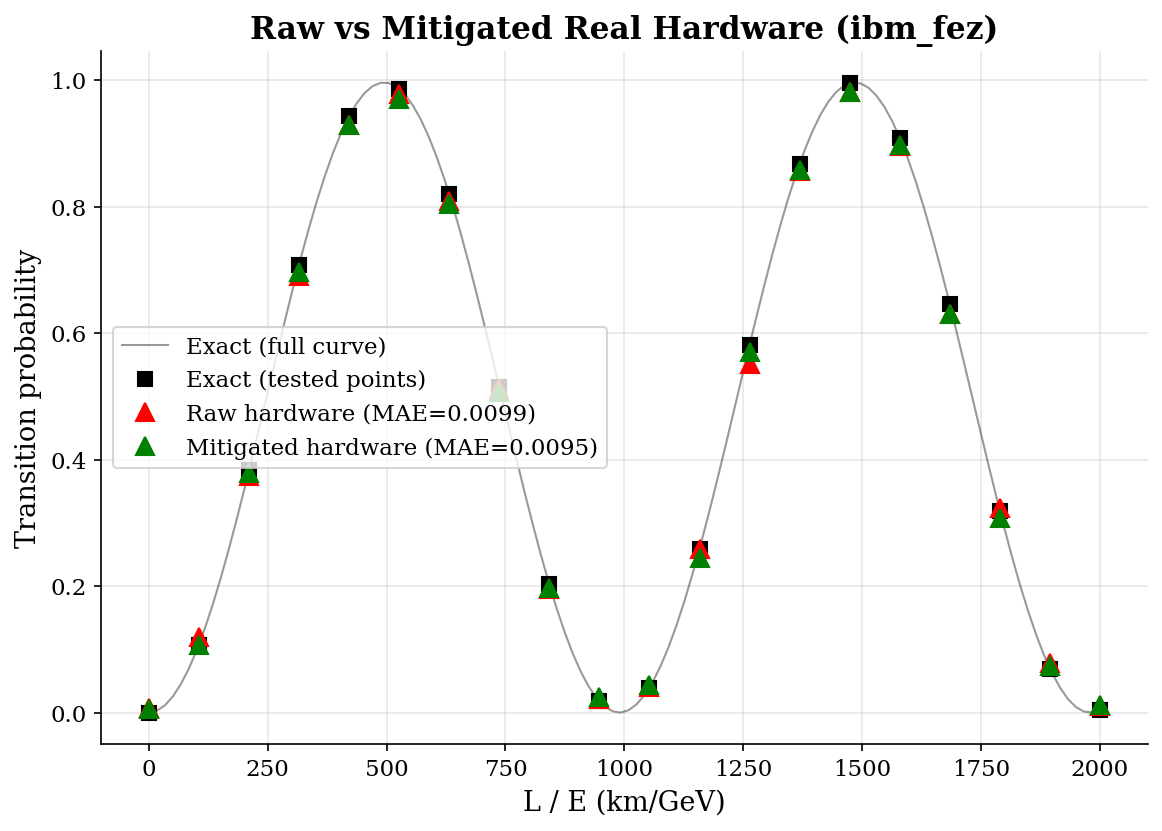

In [10]:
plt.figure(figsize=(9,6))
plt.plot(L_over_E_vals, P_exact, 'k-', linewidth=1, alpha=0.4, label="Exact (full curve)")
plt.plot(L_over_E_hardware, P_exact_hw, 'ks', markersize=7, label="Exact (tested points)")
plt.plot(L_over_E_hardware, P_raw, 'r^', markersize=9, label=f"Raw hardware (MAE={mae_raw:.4f})")
plt.plot(L_over_E_hardware, P_mitigated, 'g^', markersize=9, label=f"Mitigated hardware (MAE={mae_mitigated:.4f})")
plt.xlabel("L / E (km/GeV)")
plt.ylabel("Transition probability")
plt.title(f"Raw vs Mitigated Real Hardware ({backend.name})")
plt.legend()
plt.grid(True)
plt.savefig("fig_raw_vs_mitigated.png", dpi=200, bbox_inches='tight')
plt.show()

Threshold sensitivity across cutoffs (mean curve):
  40% cutoff: severity ≈ 1.487
  50% cutoff: severity ≈ 1.142
  60% cutoff: severity ≈ 0.855

50% threshold per seed: ['1.174', '1.130', '1.135', '1.130', '1.145']
Mean threshold: 1.143 ± 0.017


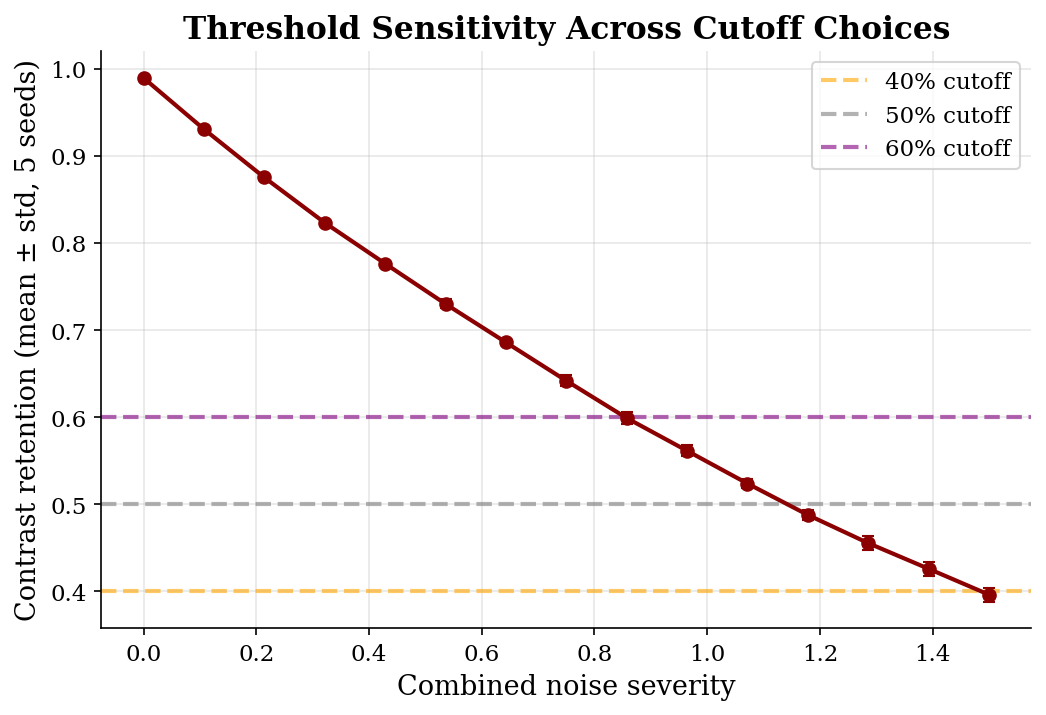

In [11]:
SEEDS_THRESHOLD = [1, 2, 3, 4, 5]
severities_extended = np.linspace(0, 1.5, 15)

# Run the full severity sweep once per seed
retention_by_seed = {seed: [] for seed in SEEDS_THRESHOLD}
for seed in SEEDS_THRESHOLD:
    for severity in severities_extended:
        nm = build_combined_noise_model(severity)
        P = np.array([run_noisy_circuit(L, theta, delta_m2, nm, seed=seed) for L in L_over_E_vals])
        retention_by_seed[seed].append(contrast_retention(P, P_exact))

retention_matrix = np.array([retention_by_seed[s] for s in SEEDS_THRESHOLD])  # shape (5 seeds, 15 severities)
retention_mean = retention_matrix.mean(axis=0)
retention_std = retention_matrix.std(axis=0)

# Find threshold (with uncertainty) for multiple cutoffs: 40%, 50%, 60%
def find_threshold(severities, retention_curve, cutoff):
    below = np.where(retention_curve < cutoff)[0]
    if len(below) == 0:
        return None
    idx = below[0]
    if idx == 0:
        return severities[0]
    # linear interpolation between idx-1 and idx for a more precise crossing point
    s0, s1 = severities[idx-1], severities[idx]
    r0, r1 = retention_curve[idx-1], retention_curve[idx]
    return s0 + (cutoff - r0) * (s1 - s0) / (r1 - r0)

print("Threshold sensitivity across cutoffs (mean curve):")
for cutoff in [0.4, 0.5, 0.6]:
    t = find_threshold(severities_extended, retention_mean, cutoff)
    print(f"  {cutoff*100:.0f}% cutoff: severity ≈ {t:.3f}" if t else f"  {cutoff*100:.0f}% cutoff: not crossed")

# Threshold uncertainty: compute threshold separately per seed, then get spread
thresholds_per_seed = [find_threshold(severities_extended, retention_matrix[i], 0.5) for i in range(len(SEEDS_THRESHOLD))]
thresholds_per_seed = [t for t in thresholds_per_seed if t is not None]
print(f"\n50% threshold per seed: {[f'{t:.3f}' for t in thresholds_per_seed]}")
print(f"Mean threshold: {np.mean(thresholds_per_seed):.3f} ± {np.std(thresholds_per_seed):.3f}")

# Plot with error bars
plt.figure(figsize=(8,5))
plt.errorbar(severities_extended, retention_mean, yerr=retention_std, fmt='o-', color='darkred', capsize=3)
for cutoff, color in [(0.4,'orange'),(0.5,'gray'),(0.6,'purple')]:
    plt.axhline(cutoff, color=color, linestyle='--', alpha=0.6, label=f'{cutoff*100:.0f}% cutoff')
plt.xlabel("Combined noise severity")
plt.ylabel("Contrast retention (mean ± std, 5 seeds)")
plt.title("Threshold Sensitivity Across Cutoff Choices")
plt.legend()
plt.grid(True)
plt.savefig("fig_threshold_sensitivity.png", dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit import transpile

backend = service.backend("ibm_marrakesh")
L_over_E_repeat = np.linspace(0.1, 2000, 10)

circuits_repeat = []
for L in L_over_E_repeat:
    phi = 2 * 1.27 * delta_m2 * L
    qc = QuantumCircuit(1, 1)
    qc.ry(2*theta, 0)
    qc.rz(phi, 0)
    qc.ry(-2*theta, 0)
    qc.measure(0, 0)
    circuits_repeat.append(transpile(qc, backend))

# --- SUBMISSION DISABLED after initial run, to prevent accidental job resubmission on "Run All" ---
# Original submission code (ran once; job IDs saved and reloaded from disk in the next cell):
#
# jobs_raw, jobs_mit = [], []
# for trial in range(3):
#     sampler_raw = Sampler(mode=backend)
#     sampler_raw.options.dynamical_decoupling.enable = False
#     sampler_raw.options.twirling.enable_gates = False
#     jobs_raw.append(sampler_raw.run(circuits_repeat, shots=2000))
#
#     sampler_mit = Sampler(mode=backend)
#     sampler_mit.options.dynamical_decoupling.enable = True
#     sampler_mit.options.dynamical_decoupling.sequence_type = "XpXm"
#     sampler_mit.options.twirling.enable_gates = True
#     jobs_mit.append(sampler_mit.run(circuits_repeat, shots=2000))
#
# print("RAW job IDs:", [j.job_id() for j in jobs_raw])
# print("MITIGATED job IDs:", [j.job_id() for j in jobs_mit])

print("Submission disabled — jobs already ran once. Job IDs are reloaded from disk in the next cell.")


Submission disabled — jobs already ran once. Job IDs are reloaded from disk in the next cell.


In [13]:
job_ids_raw = ['d9so3q1dsedc73ai0v8g', 'd9so3q9dsedc73ai0va0', 'd9so3qvpemts73ctvh70']
job_ids_mit = ['d9so3q9dsedc73ai0v9g', 'd9so3qhdsedc73ai0vb0', 'd9so3qvtfhrs73dt1760']

jobs_raw = [service.job(jid) for jid in job_ids_raw]
jobs_mit = [service.job(jid) for jid in job_ids_mit]

print("Raw statuses:", [j.status() for j in jobs_raw])
print("Mitigated statuses:", [j.status() for j in jobs_mit])

Raw statuses: ['DONE', 'DONE', 'DONE']
Mitigated statuses: ['DONE', 'DONE', 'DONE']


In [14]:
print(backend.name)

ibm_marrakesh


In [15]:
L_over_E_repeat = np.linspace(0.1, 2000, 10)
P_exact_repeat = np.array([exact_transition_probability(L, theta, delta_m2) for L in L_over_E_repeat])

circuits_repeat = []
for L in L_over_E_repeat:
    phi = 2 * 1.27 * delta_m2 * L
    qc = QuantumCircuit(1, 1)
    qc.ry(2*theta, 0)
    qc.rz(phi, 0)
    qc.ry(-2*theta, 0)
    qc.measure(0, 0)
    circuits_repeat.append(transpile(qc, backend))

print("circuits_repeat defined, length:", len(circuits_repeat))

circuits_repeat defined, length: 10


In [16]:
print(len(jobs_raw), len(jobs_mit))

3 3


In [17]:
L_over_E_repeat = np.linspace(0.1, 2000, 10)
P_exact_repeat = np.array([exact_transition_probability(L, theta, delta_m2) for L in L_over_E_repeat])

# Adding definition for circuits_repeat from cell akdLCK8zNUjo
circuits_repeat = []
for L in L_over_E_repeat:
    phi = 2 * 1.27 * delta_m2 * L
    qc = QuantumCircuit(1, 1)
    qc.ry(2*theta, 0)
    qc.rz(phi, 0)
    qc.ry(-2*theta, 0)
    qc.measure(0, 0)
    circuits_repeat.append(transpile(qc, backend))

mae_raw_trials, mae_mit_trials = [], []
for jr, jm in zip(jobs_raw, jobs_mit):
    rr, rm = jr.result(), jm.result()
    P_r = np.array([rr[i].data.c.get_counts().get('1',0)/2000 for i in range(len(circuits_repeat))])
    P_m = np.array([rm[i].data.c.get_counts().get('1',0)/2000 for i in range(len(circuits_repeat))])
    mae_raw_trials.append(np.mean(np.abs(P_r - P_exact_repeat)))
    mae_mit_trials.append(np.mean(np.abs(P_m - P_exact_repeat)))

print(f"Raw MAE across 3 trials: {mae_raw_trials}, mean={np.mean(mae_raw_trials):.4f}±{np.std(mae_raw_trials):.4f}")
print(f"Mitigated MAE across 3 trials: {mae_mit_trials}, mean={np.mean(mae_mit_trials):.4f}±{np.std(mae_mit_trials):.4f}")

from scipy import stats
t_stat, p_val = stats.ttest_ind(mae_raw_trials, mae_mit_trials)
print(f"\nPaired t-test: t={t_stat:.3f}, p={p_val:.3f}")
print("Significant at p<0.05" if p_val < 0.05 else "NOT statistically significant at p<0.05 — likely within backend drift")

Raw MAE across 3 trials: [np.float64(0.012122817321508302), np.float64(0.012197821272677713), np.float64(0.015222817321508302)], mean=0.0132±0.0014
Mitigated MAE across 3 trials: [np.float64(0.015572817321508309), np.float64(0.015347821272677715), np.float64(0.011322817321508295)], mean=0.0141±0.0020

Paired t-test: t=-0.524, p=0.628
NOT statistically significant at p<0.05 — likely within backend drift


In [18]:
job_raw_4 = service.job("d9t4gi0pdb6s73e6o6i0")
job_mit_4 = service.job("d9t4gihdsedc73aifiv0")

print("Trial 4 raw status:", job_raw_4.status())
print("Trial 4 mitigated status:", job_mit_4.status())

Trial 4 raw status: DONE
Trial 4 mitigated status: DONE


In [19]:
rr4, rm4 = job_raw_4.result(), job_mit_4.result()
P_r4 = np.array([rr4[i].data.c.get_counts().get('1',0)/2000 for i in range(len(circuits_repeat))])
P_m4 = np.array([rm4[i].data.c.get_counts().get('1',0)/2000 for i in range(len(circuits_repeat))])

mae_raw_4 = np.mean(np.abs(P_r4 - P_exact_repeat))
mae_mit_4 = np.mean(np.abs(P_m4 - P_exact_repeat))

mae_raw_all = mae_raw_trials + [mae_raw_4]
mae_mit_all = mae_mit_trials + [mae_mit_4]

print(f"All 4 raw MAEs: {[f'{x:.4f}' for x in mae_raw_all]}")
print(f"All 4 mitigated MAEs: {[f'{x:.4f}' for x in mae_mit_all]}")
print(f"Raw mean±SD: {np.mean(mae_raw_all):.4f} ± {np.std(mae_raw_all):.4f}")
print(f"Mitigated mean±SD: {np.mean(mae_mit_all):.4f} ± {np.std(mae_mit_all):.4f}")

t_stat, p_val = stats.ttest_ind(mae_raw_all, mae_mit_all)
print(f"\n4-trial t-test: t={t_stat:.3f}, p={p_val:.3f}")
print("Significant at p<0.05" if p_val < 0.05 else "NOT statistically significant at p<0.05")

All 4 raw MAEs: ['0.0121', '0.0122', '0.0152', '0.0119']
All 4 mitigated MAEs: ['0.0156', '0.0153', '0.0113', '0.0142']
Raw mean±SD: 0.0129 ± 0.0014
Mitigated mean±SD: 0.0141 ± 0.0017

4-trial t-test: t=-0.986, p=0.362
NOT statistically significant at p<0.05
